<a href="https://colab.research.google.com/github/Muse-M/FinalYearProject/blob/main/QSO_%2B_Many_gal_%2B_Noise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

should I predict gal type still?

## Imports

In [1]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling n

In [2]:
# Pytorch imports
import torch
import torch.utils.data as data
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
import captum
from captum.attr import (
    GradientShap,
    DeepLift,
    DeepLiftShap,
    IntegratedGradients,
    LayerConductance,
    NeuronConductance,
    NoiseTunnel)

# General Python imports
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif" # Standardise font throughout whole notebook
from   matplotlib.ticker import AutoMinorLocator
import seaborn as sns
import numpy as np
import os
import pandas as pd
import pickle
from datetime import datetime
import joblib

# Quality of life imports
from tqdm.notebook import tqdm # progress Bar
from accelerate import Accelerator

# data processing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Import tensorboard logger from PyTorch
from torch.utils.tensorboard import SummaryWriter
# Load tensorboard extension for Jupyter Notebook, only need to start TB in the notebook
%load_ext tensorboard

In [3]:
################UoA code################
torch.manual_seed(42) # Setting the seed

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)

# GPU operations have a separate seed we also want to set
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

# Additionally, some operations on a GPU are implemented stochastic for efficiency
# We want to ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Device cpu


## data load

In [4]:
dataPath='/content/drive/MyDrive/many qso + many gal + noise 2'
filePaths=[]
for i in os.listdir(dataPath):
  filePaths.append(os.path.join(dataPath, i))


In [5]:
from functools import total_ordering
from concurrent.futures import ThreadPoolExecutor

def load_pickle(file_path ):
    a=filePaths.index(file_path)
    if a%1000==0:
        print(str(a)+'/10000')
    with open(file_path, "rb") as f:
        try:
            data = pickle.load(f)
            data['wl'] = data['wl'].flatten()
            df=pd.DataFrame(data)
            df_single_row = pd.DataFrame({col: [df[col].tolist()] for col in df.columns})
            return df_single_row
        except Exception as e:
            print(f"Error loading file: {file_path[len(dataPath):]} | {e}")

# Load files in parallel
# Loads each pickle file from drive as a dataframe with 1 row and adds to list dataframes
with ThreadPoolExecutor() as executor:
    dataframes = list(executor.map(load_pickle, filePaths))



# concatenate all dataframes into 1 dataframe
final_df = pd.concat(dataframes, ignore_index=True)
final_df.shape

0/10000
1000/10000
2000/10000
3000/10000
4000/10000
5000/10000
6000/10000
7000/10000
8000/10000
9000/10000


(10000, 9)

In [6]:
final_df.head()

,wl,flux,error,true_AGN,true_gal,gal_type,f_gal,dn4000,hdelta
0,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.5541673392094297, 1.3225747008492952, 1.265...","[0.16782325506210327, 0.17028498649597168, 0.1...","[1.2432820221589387, 1.255101425744072, 1.2503...","[0.12757887022121728, 0.12579016471812526, 0.1...","[red, red, red, red, red, red, red, red, red, ...","[0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.2...","[1.9055955462768537, 1.9055955462768537, 1.905...","[-1.466245245968707, -1.466245245968707, -1.46..."
1,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.6344360118186462, 0.6935755604743681, 0.927...","[0.16771212220191956, 0.17017221450805664, 0.1...","[0.40994706303873707, 0.4143232409239085, 0.41...","[0.43206717530653954, 0.4257598032014178, 0.42...","[red, red, red, red, red, red, red, red, red, ...","[0.74, 0.74, 0.74, 0.74, 0.74, 0.74, 0.74, 0.7...","[1.8962762902563093, 1.8962762902563093, 1.896...","[-1.5121581382752982, -1.5121581382752982, -1...."
2,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.7224323168523532, 0.6949719199082263, 0.696...","[0.179845929145813, 0.18248401582241058, 0.156...","[0.2070699838436622, 0.2075124199099574, 0.205...","[0.4848594770091066, 0.476854106899805, 0.4666...","[red, red, red, red, red, red, red, red, red, ...","[0.86, 0.86, 0.86, 0.86, 0.86, 0.86, 0.86, 0.8...","[1.9228175140027075, 1.9228175140027075, 1.922...","[-1.2747974793001169, -1.2747974793001169, -1...."
3,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.3637194564556518, 1.320017855673046, 1.4522...","[0.16670522093772888, 0.16915056109428406, 0.1...","[1.345298455648995, 1.3380370470273852, 1.3300...","[0.06045951286509939, 0.05965183564302408, 0.0...","[red, red, red, red, red, red, red, red, red, ...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...","[1.81027654592034, 1.81027654592034, 1.8102765...","[-0.8497407749135834, -0.8497407749135834, -0...."
4,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.2316810639819922, 0.7196227889323984, 1.107...","[0.16914483904838562, 0.17162594199180603, 0.1...","[0.44269832382739227, 0.4449831221213189, 0.43...","[0.4100060694417681, 0.40457858775258887, 0.39...","[red, red, red, red, red, red, red, red, red, ...","[0.71, 0.71, 0.71, 0.71, 0.71, 0.71, 0.71, 0.7...","[1.9166287600600451, 1.9166287600600451, 1.916...","[-1.532779964391233, -1.532779964391233, -1.53..."


In [7]:
firstDataset=final_df.copy(deep=True)
# converts columns that should be single valued into single values i.e [0.01,0.01,0.01....] => 0.01
firstDataset['f_gal'] = firstDataset['f_gal'].apply(lambda x: x[0])
firstDataset['gal_type'] = firstDataset['gal_type'].apply(lambda x: x[0])
firstDataset['dn4000'] = firstDataset['dn4000'].apply(lambda x: x[0])
firstDataset['hdelta'] = firstDataset['hdelta'].apply(lambda x: x[0])


# transforms categorical gal_types into numeric
le = LabelEncoder()
firstDataset['gal_type_code'] = le.fit_transform(firstDataset['gal_type'])

In [8]:
firstDataset.head()

,wl,flux,error,true_AGN,true_gal,gal_type,f_gal,dn4000,hdelta,gal_type_code
0,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.5541673392094297, 1.3225747008492952, 1.265...","[0.16782325506210327, 0.17028498649597168, 0.1...","[1.2432820221589387, 1.255101425744072, 1.2503...","[0.12757887022121728, 0.12579016471812526, 0.1...",red,0.22,1.905596,-1.466245,4
1,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.6344360118186462, 0.6935755604743681, 0.927...","[0.16771212220191956, 0.17017221450805664, 0.1...","[0.40994706303873707, 0.4143232409239085, 0.41...","[0.43206717530653954, 0.4257598032014178, 0.42...",red,0.74,1.896276,-1.512158,4
2,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.7224323168523532, 0.6949719199082263, 0.696...","[0.179845929145813, 0.18248401582241058, 0.156...","[0.2070699838436622, 0.2075124199099574, 0.205...","[0.4848594770091066, 0.476854106899805, 0.4666...",red,0.86,1.922818,-1.274797,4
3,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.3637194564556518, 1.320017855673046, 1.4522...","[0.16670522093772888, 0.16915056109428406, 0.1...","[1.345298455648995, 1.3380370470273852, 1.3300...","[0.06045951286509939, 0.05965183564302408, 0.0...",red,0.10,1.810277,-0.849741,4
4,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.2316810639819922, 0.7196227889323984, 1.107...","[0.16914483904838562, 0.17162594199180603, 0.1...","[0.44269832382739227, 0.4449831221213189, 0.43...","[0.4100060694417681, 0.40457858775258887, 0.39...",red,0.71,1.916629,-1.532780,4


<Axes: >

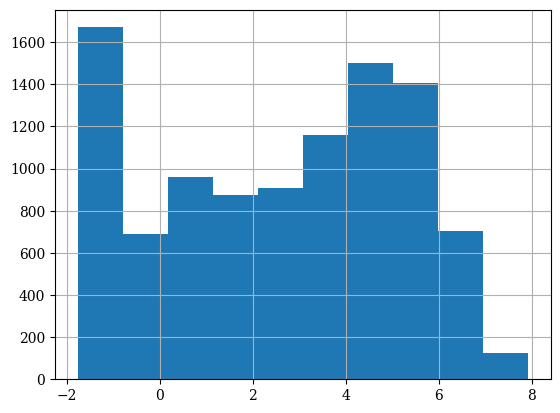

In [9]:
firstDataset['hdelta'].hist()

<Axes: >

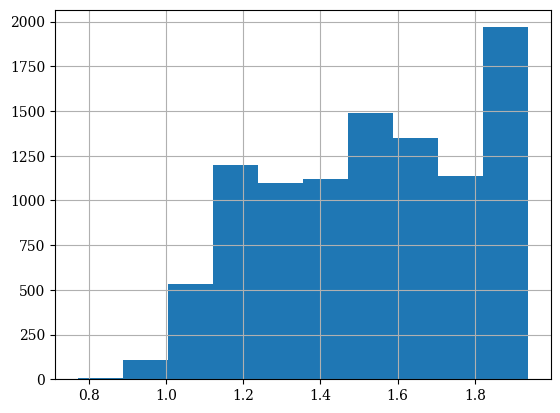

In [10]:
firstDataset['dn4000'].hist()

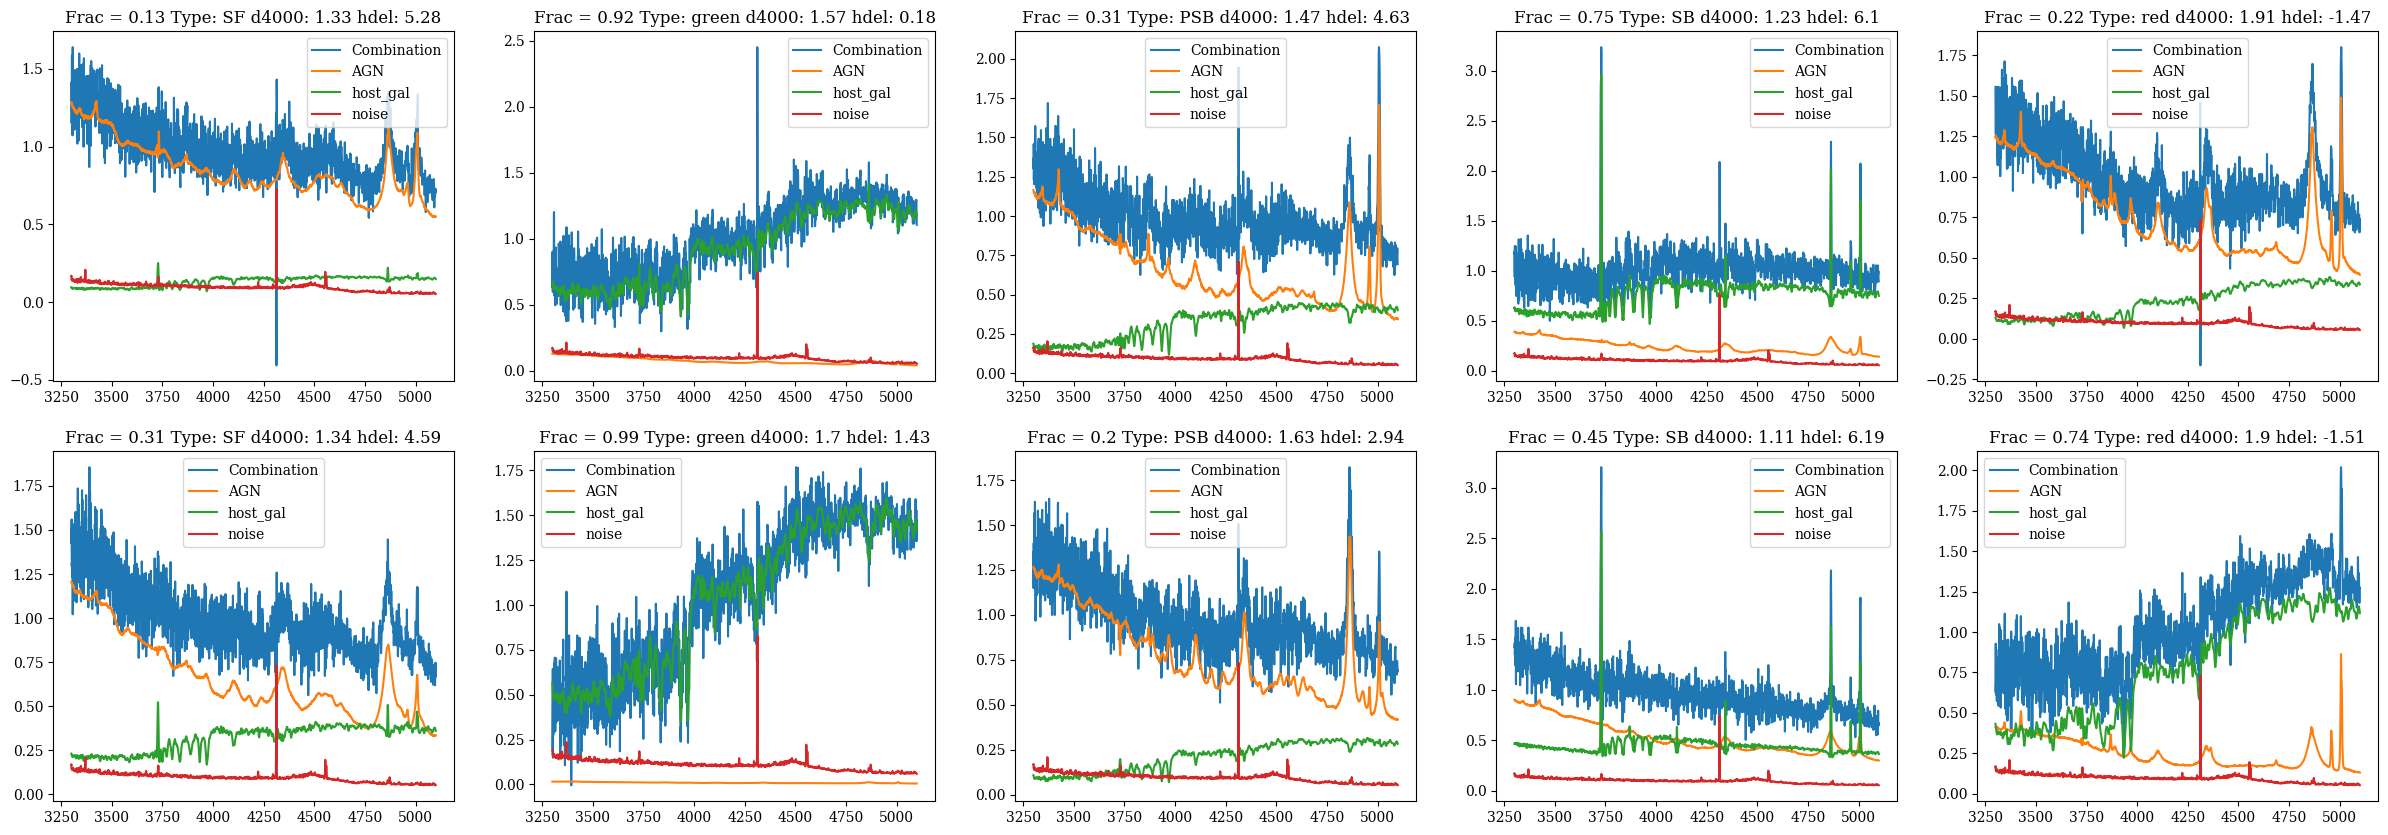

In [11]:
types= ['SF',  'green', 'PSB', 'SB', 'red']
fig, ax = plt.subplots(figsize=(30,10), ncols=5, nrows=2)
uniqueType=[]

i=0
graph=0

while len(uniqueType) < 10: # plot spectra if that gal_type is new
    singleRow=firstDataset.iloc[[i]]
    wl= singleRow['wl'].iloc[0]
    flux= singleRow['flux'].iloc[0]
    true_AGN= singleRow['true_AGN'].iloc[0]
    true_gal= singleRow['true_gal'].iloc[0]
    noise_array=singleRow['error'].iloc[0]
    gal_type=singleRow['gal_type'].iloc[0]
    f_gal= singleRow['f_gal'].iloc[0]
    d4000= singleRow['dn4000'].iloc[0]
    hdel= singleRow['hdelta'].iloc[0]

    i+=1

    typecount=uniqueType.count(gal_type)

    if typecount>=2:
        pass
    else:
        ax[typecount,types.index(gal_type)].plot(wl, flux, label='Combination')
        ax[typecount,types.index(gal_type)].plot(wl, true_AGN, label='AGN')
        ax[typecount,types.index(gal_type)].plot(wl, true_gal, label='host_gal')
        ax[typecount,types.index(gal_type)].plot(wl, noise_array, label='noise')
        ax[typecount,types.index(gal_type)].set_title('Frac = '+str(f_gal)+ ' Type: '+ gal_type + ' d4000: ' +str(round(d4000,2)) + ' hdel: ' + str(round(hdel,2)))
        ax[typecount,types.index(gal_type)].legend()
        if typecount==1:
            graph+=1
        uniqueType.append(gal_type)




### make dataloaders for the simul traning model


In [12]:
# Dataset class for simultaneous traning model
class fullDataSetClass(torch.utils.data.Dataset):
  def __init__(self, flux, fraction, galTypeCode,dn4000,hdelta):
    self.data=flux
    self.f_gal=fraction
    self.galTypeCode=galTypeCode
    self.dn4=dn4000
    self.hdelta=hdelta
    self.generateData()
    self.size=len(self.data)

  def generateData(self): # a single datum contains data=spectra flux, label=f_gal, galtypecode(for potential graphing use)
    self.tensordata=torch.Tensor(self.data)
    self.tensorF_gal=torch.Tensor(self.f_gal)
    self.tensorGalTypeCode=torch.Tensor(self.galTypeCode)
    self.tensordn4=torch.Tensor(self.dn4)
    self.tensorhdel=torch.Tensor(self.hdelta)


  # define __getitem__, and __len__ to define pytorch dataset, allows you use dataset[index] wihout needed to do dataset.getitem(index)
  def __getitem__(self, index):
    data_point = self.tensordata[index]
    data_f_gal = self.tensorF_gal[index]
    gal_typeCode = self.tensorGalTypeCode[index]
    dn4_indexed = self.tensordn4[index]
    hdelta_indexed = self.tensorhdel[index]

    return data_point, data_f_gal, gal_typeCode, dn4_indexed,hdelta_indexed

  def  __len__(self):
    return self.size

#create dataset
fullDataset_simul_traning=fullDataSetClass(firstDataset['flux'], firstDataset['f_gal'], firstDataset['gal_type_code'],firstDataset['dn4000'],firstDataset['hdelta'])

In [13]:
#split data set into train, validation, test (8800,200,1000)
trainDataset, testDataset = torch.utils.data.random_split(fullDataset_simul_traning, [9000,1000])
trainDataset, validDataset = torch.utils.data.random_split(trainDataset, [8800,200])

In [14]:
import torch.utils.data as data
# Split data into batches. Also splits data from label, useful when traning the classifier but model is already trained and being loaded in

TRAIN_BATCH_SIZE=40
VALID_BATCH_SIZE=100
train_data_loader = data.DataLoader(trainDataset, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader = data.DataLoader(validDataset, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader = data.DataLoader(testDataset, batch_size=500, shuffle=False)

In [15]:
for batch_flux, batch_f_gal,batch_galType_code, batch_dn4, batch_hdel in train_data_loader:
    print(batch_flux, batch_f_gal,batch_galType_code, batch_dn4, batch_hdel)
    break

tensor([[0.9686, 0.4948, 0.9471,  ..., 1.2115, 1.1104, 1.1828],
        [1.9363, 1.8064, 1.8095,  ..., 0.4449, 0.3347, 0.5380],
        [1.4573, 1.4715, 1.7817,  ..., 0.5981, 0.5515, 0.5707],
        ...,
        [1.3208, 1.3780, 1.3459,  ..., 0.8968, 0.8725, 0.9067],
        [1.2045, 1.1437, 1.3998,  ..., 0.6689, 0.7606, 0.6783],
        [1.1964, 1.0763, 1.0374,  ..., 0.8915, 1.0118, 0.9889]]) tensor([0.8100, 0.0200, 0.4100, 0.9600, 0.6300, 0.5400, 0.6200, 0.3800, 0.1100,
        0.5700, 0.7200, 0.8500, 0.5100, 0.5900, 0.7200, 0.1900, 0.6200, 0.2800,
        0.1300, 0.5700, 0.8100, 0.6200, 0.9500, 0.9200, 0.8900, 0.3900, 0.2600,
        0.7800, 0.7100, 0.1400, 0.0200, 0.4900, 0.6200, 0.7400, 0.5400, 0.4800,
        0.4800, 0.4400, 0.0500, 0.4600]) tensor([0., 1., 1., 1., 4., 1., 2., 1., 0., 0., 3., 1., 2., 3., 3., 1., 4., 1.,
        2., 2., 0., 0., 3., 2., 4., 3., 2., 1., 3., 4., 4., 4., 3., 3., 3., 4.,
        1., 3., 4., 4.]) tensor([1.5032, 1.1415, 1.0729, 1.0502, 1.8373, 0.9335, 

### Make datset for the individual training

In [16]:
# Dataset class for individual traning model
class individualDataSetClass(torch.utils.data.Dataset):
  def __init__(self, flux, label, type_hue):
    self.data=flux
    self.label=label
    self.hue=type_hue

    self.generateData()
    self.size=len(self.data)

  def generateData(self): # a single datum contains data=spectra flux, label=f_gal, galtypecode(for potential graphing use)
    self.tensordata=torch.Tensor(self.data)
    self.tensorLabel=torch.Tensor(self.label)
    self.tensorHue=torch.Tensor(self.hue)

  # define __getitem__, and __len__ to define pytorch dataset, allows you use dataset[index] wihout needed to do dataset.getitem(index)
  def __getitem__(self, index):
    data_point = self.tensordata[index]
    data_label = self.tensorLabel[index]
    data_hue = self.tensorHue[index]


    return data_point, data_label, data_hue

  def  __len__(self):
    return self.size

#create dataset
f_gal_dataset=individualDataSetClass(firstDataset['flux'], firstDataset['f_gal'], firstDataset['gal_type_code'])
dn4000_dataset=individualDataSetClass(firstDataset['flux'], firstDataset['dn4000'],firstDataset['gal_type_code'])
hdelta_dataset=individualDataSetClass(firstDataset['flux'], firstDataset['hdelta'],firstDataset['gal_type_code'])

In [17]:
trainDataset_f_gal, testDataset_f_gal = torch.utils.data.random_split(f_gal_dataset, [9000,1000])
trainDataset_f_gal, validDataset_f_gal = torch.utils.data.random_split(trainDataset_f_gal, [8800,200])

trainDataset_dn4, testDataset_dn4 = torch.utils.data.random_split(dn4000_dataset, [9000,1000])
trainDataset_dn4, validDataset_dn4 = torch.utils.data.random_split(trainDataset_dn4, [8800,200])

trainDataset_hdel, testDataset_hdel = torch.utils.data.random_split(hdelta_dataset, [9000,1000])
trainDataset_hdel, validDataset_hdel = torch.utils.data.random_split(trainDataset_hdel, [8800,200])

In [18]:
TRAIN_BATCH_SIZE=40
VALID_BATCH_SIZE=100

train_data_loader_fgal = data.DataLoader(trainDataset_f_gal, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_fgal = data.DataLoader(validDataset_f_gal, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader_fgal = data.DataLoader(testDataset_f_gal, batch_size=500, shuffle=False)

train_data_loader_dn4 = data.DataLoader(trainDataset_dn4, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_dn4 = data.DataLoader(validDataset_dn4, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader_dn4= data.DataLoader(testDataset_dn4, batch_size=500, shuffle=False)

train_data_loader_hdelta = data.DataLoader(trainDataset_hdel, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_hdelta = data.DataLoader(validDataset_hdel, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader_hdelta = data.DataLoader(testDataset_hdel, batch_size=500, shuffle=False)


## ResNet50 Model

### Class

In [19]:
class singleBlock(nn.Module):
    def __init__(self, input_ch, output_ch, kernel, stride):
        super().__init__()

        pad=int((kernel-1)/2)
        self.conv=nn.Conv1d(input_ch, output_ch, kernel, stride, pad)
        self.bn=nn.BatchNorm1d(output_ch)

    def forward(self, x):
        x= self.conv(x)
        x= self.bn(x)
        return x


class residualBlock(nn.Module):
    def __init__(self, input_ch, output_ch, downsample,firstLayerInBlock, stride, bottleNeckRequired):
        super().__init__()

        if firstLayerInBlock:
            downSampleFactor=2
            self.input_ch=int(input_ch/2)
        else:
            downSampleFactor=4
            self.input_ch=input_ch


        self.output_ch=output_ch
        if bottleNeckRequired:
            self.bottleNeckChannelSize=int(self.input_ch/downSampleFactor)
        else:
            self.bottleNeckChannelSize=self.input_ch

        self.conv1=singleBlock(self.input_ch, self.bottleNeckChannelSize, 1, 1)
        self.conv2=singleBlock(self.bottleNeckChannelSize,self.bottleNeckChannelSize,3,stride)
        self.conv3=singleBlock(self.bottleNeckChannelSize, self.output_ch,1,1)
        self.act= nn.ReLU()

        self.downsample=downsample
        if self.input_ch != self.output_ch:
            self.downsample=True
        if self.downsample:
            self.downsampleConv=singleBlock(self.input_ch, self.output_ch, 1,stride)

    def forward(self, x):

        f=self.act(self.conv1(x))
        f=self.act(self.conv2(f))
        f=self.conv3(f)

        if self.downsample:
            x=self.downsampleConv(x)

        h=f+x
        return self.act(h)



class fullResNetModel50(nn.Module):
    def __init__(self, dataChannels, blockList, channelList, finalOutputNo, bottleNeckRequired, stride,**kwargs):
        super().__init__()

        self.blockList=blockList
        self.channelList=channelList
        self.classes=finalOutputNo
        self.stride=stride

        self.firstConv=nn.Conv1d(dataChannels, self.channelList[0], 3,2,3)
        self.BN=nn.BatchNorm1d(self.channelList[0])
        self.act=nn.ReLU()
        self.maxPool=nn.MaxPool1d(3,2,1)

        if self.channelList[0] != self.channelList[1]:
            # takes output from input layer and increase number of channels to size needed to make sure it can add with the first block of middle layers
            self.middleLayerFirstPartUpsample=nn.Conv1d(self.channelList[0], self.channelList[1], 1,1,0)

        self.bottleNeckRequired=bottleNeckRequired # if high number of filters, downsample is needed at the start of layers


        self._createNetwork()
        self._initWeights()


    def _createNetwork(self):
        self.inputLayer=nn.Sequential(
            self.firstConv,
            self.BN,
            self.act,
            self.maxPool
        )



        self.middleLayersPart1=nn.Sequential(
            singleBlock(self.channelList[0], self.channelList[0], 1, 1),
            nn.ReLU(),
            singleBlock(self.channelList[0],self.channelList[0], 3, 1),
            nn.ReLU(),
            singleBlock(self.channelList[0], self.channelList[1], 1, 1),
        )

        self.blockList[1]=self.blockList[1]-1

        self.middleLayersPart2=nn.Sequential()

        for layer in range(1,len(self.blockList)):
            for i in range(self.blockList[layer]):
                #print('layer', layer, 'block', i)

                firstLayerInBlock = True if (i==0 and layer !=1 and self.channelList[layer] != self.channelList[layer-1] ) else False
                stride=self.stride[layer]
                downsample=True if stride == 2 else False # required when size of input and output dont match, which is when stride isnt 1 or inbetween different residual block, the second case is checked in the class

                self.middleLayersPart2.add_module(str(layer)+' '+str(i),
                                                  residualBlock(self.channelList[layer],
                                                                self.channelList[layer],
                                                                downsample,
                                                                firstLayerInBlock,
                                                                stride,
                                                                self.bottleNeckRequired))

        self.outputLayers=nn.Sequential(
            nn.AdaptiveAvgPool1d(1), # reduces to 1 value per channel
            nn.Flatten(),
            nn.Linear(self.channelList[-1], self.classes)
        )


    def _initWeights(self):
        for m in self.modules():
            if (isinstance(m,nn.Conv1d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu') # test different intialisations, different modes
            elif (isinstance(m, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x=self.inputLayer(x)
        identity=x
        x=self.middleLayersPart1(x) # first block of first layer in middle part

        if self.channelList[0] != self.channelList[1]:
            identity=self.middleLayerFirstPartUpsample(identity)
        x=identity+x
        x=self.act(x)

        x=self.middleLayersPart2(x)
        x=self.outputLayers(x)
        return x


## Individual CNNs

In [74]:
def trainModelResNet(model, traindataLoader, validdataLoader, optimiser, lossCalculator, epochs, scheduler,verbose):

    #train on traning set epochs times
    for epoch in tqdm(range(epochs)):
        epoch_train_loss=0
        epoch_valid_loss=0
        model.train()
        for batch_data, batch_label, _ in traindataLoader:
            batch_data=batch_data.unsqueeze(1)
            batch_data=batch_data.to(device) # brings data to cpu or gpu
            batch_label=batch_label.to(device)

            prediction=model(batch_data).squeeze()
            loss= lossCalculator(prediction, batch_label)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            epoch_train_loss += loss.item() # per batch

        # Add average loss to TensorBoard
        epoch_train_loss /= len(traindataLoader) #average over number of batches
        epoch_valid_loss+=validate_model(model, validdataLoader, lossCalculator) # (already averaged)

        scheduler.step(epoch_valid_loss) # if validation score hasn't decreased in a while, reduce learning rate by factor of 10

        if verbose==True: # Check if loss should be ouput after epochs
            if epochs > 19: # if number of total epochs is too large
                if epoch%10 == 0: # print every 10
                    print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])
            else: # print after each epoch
                print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])


    return [epoch_train_loss, epoch_valid_loss]


def validate_model(model, validdataLoader, lossCalculator):
    model.eval() # set into eval mode to not update gradients when using validation data
    with torch.no_grad():
        lossValue=0
        for batch_data, batch_label, _ in validdataLoader:
            batch_data=batch_data.unsqueeze(1)
            batch_data=batch_data.to(device)
            batch_label=batch_label.to(device)

            prediction=model(batch_data).squeeze()
            lossValue+=lossCalculator(prediction, batch_label)

        lossValue /= len(validdataLoader)
    return lossValue

In [33]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_fgal_indv=fullResNetModel50(1, blockList, channelList,1, False, stride)


In [34]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_dn4_indv=fullResNetModel50(1, blockList, channelList,1, False, stride)

In [35]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_hdelta_indv=fullResNetModel50(1, blockList, channelList,1, False, stride)

In [36]:
optimiser= torch.optim.SGD(model_fgal_indv.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_fgal_indv.to(device)
loss= nn.MSELoss()
trainModelResNet(model_fgal_indv, train_data_loader_fgal, valid_data_loader_fgal, optimiser,
                 loss, 10, lrScheduler,verbose=True)

model_dn4_indv.to(device)
loss= nn.MSELoss()
trainModelResNet(model_dn4_indv, train_data_loader_dn4, valid_data_loader_dn4, optimiser,
                 loss, 10, lrScheduler,verbose=True)

model_hdelta_indv.to(device)
loss= nn.MSELoss()
trainModelResNet(model_hdelta_indv, train_data_loader_hdelta, valid_data_loader_hdelta, optimiser,
                 loss, 10, lrScheduler,verbose=True)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  0.08472650653372209 Valid loss: tensor(0.0619) lr 0.001
Epoch No: 2 Train loss:  0.0449381557914118 Valid loss: tensor(0.0407) lr 0.001
Epoch No: 3 Train loss:  0.03691177989045779 Valid loss: tensor(0.0324) lr 0.001
Epoch No: 4 Train loss:  0.029985062529643378 Valid loss: tensor(0.0282) lr 0.001
Epoch No: 5 Train loss:  0.02511538458056748 Valid loss: tensor(0.0256) lr 0.001
Epoch No: 6 Train loss:  0.021781624853610994 Valid loss: tensor(0.0204) lr 0.001


KeyboardInterrupt: 

## Individually trained but connected CNNs

- connect at start
- connect at fully connected section

### connected at the start

In [246]:
def trainModelResNet_sequential(model, traindataLoader, validdataLoader, optimiser, lossCalculator, epochs, scheduler,verbose):

    #train on traning set epochs times
    for epoch in tqdm(range(epochs)):
        epoch_train_loss=0
        epoch_valid_loss=0
        model.train()
        for batch_data, batch_label, _, _,_ in traindataLoader:

            batch_data=batch_data.to(device) # brings data to cpu or gpu
            batch_label=batch_label.to(device)

            prediction=model(batch_data).squeeze()
            loss= lossCalculator(prediction, batch_label)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            epoch_train_loss += loss.item() # per batch

        # Add average loss to TensorBoard
        epoch_train_loss /= len(traindataLoader) #average over number of batches
        epoch_valid_loss+=validate_model_sequential(model, validdataLoader, lossCalculator) # (already averaged)

        scheduler.step(epoch_valid_loss) # if validation score hasn't decreased in a while, reduce learning rate by factor of 10

        if verbose==True: # Check if loss should be ouput after epochs
            if epochs > 19: # if number of total epochs is too large
                if epoch%10 == 0: # print every 10
                    print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])
            else: # print after each epoch
                print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])


    return [epoch_train_loss, epoch_valid_loss]


def validate_model_sequential(model, validdataLoader, lossCalculator):
    model.eval() # set into eval mode to not update gradients when using validation data
    with torch.no_grad():
        lossValue=0
        for batch_data, batch_label, _ ,_,_ in validdataLoader:
            batch_data=batch_data.to(device)
            batch_label=batch_label.to(device)

            prediction=model(batch_data).squeeze()
            lossValue+=lossCalculator(prediction, batch_label)

        lossValue /= len(validdataLoader)
    return lossValue

In [191]:
# dataset for individual trained but attach the prediction of the previous model to new input data
class MASTERDATASET(torch.utils.data.Dataset):
  def __init__(self, flux, f_gal, dn4000, hdelta, type_hue):
    self.data=flux
    self.f_gal=f_gal
    self.dn4000=dn4000
    self.hdelta=hdelta
    self.hue=type_hue

    self.generateData()
    self.size=len(self.data)

  def generateData(self):
    self.tensordata=torch.Tensor(self.data)
    self.tensorf_gal=torch.Tensor(self.f_gal)
    self.tensor_dn4000=torch.Tensor(self.dn4000)
    self.tensor_hdelta=torch.Tensor(self.hdelta)
    self.tensor_Hue=torch.Tensor(self.hue)

  def __getitem__(self, index):
    data_point = self.tensordata[index]
    data_f_gal = self.tensorf_gal[index]
    data_dn400 =self.tensor_dn4000[index]
    data_hdelta =self.tensor_hdelta[index]
    data_hue = self.tensor_Hue[index]


    return data_point, data_f_gal, data_dn400, data_hdelta, data_hue

  def  __len__(self):
    return self.size

#create dataset
masterData=MASTERDATASET(firstDataset['flux'], firstDataset['f_gal'], firstDataset['dn4000'], firstDataset['hdelta'], firstDataset['gal_type_code'])


In [260]:
# dataset for individual trained but attach the prediction of the previous model to new input data
class modifiedDataset(torch.utils.data.Dataset):
    def __init__(self, masterData, predicted_Data_f_gal, predicted_Data_dn4000, dataName):
        self.master=masterData
        self.predicted_Data_fgal=predicted_Data_f_gal
        self.predicted_Data_dn4000=predicted_Data_dn4000
        self.dataName=dataName

        self.generateData()
        self.size=len(self.master)

    def generateData(self):
        self.tensorPredicted_fgal=torch.Tensor(self.predicted_Data_fgal) if self.predicted_Data_fgal != None else None
        self.tensorPredicted_dn4000=torch.Tensor(self.predicted_Data_dn4000) if self.predicted_Data_dn4000 != None else None



    def __getitem__(self, index):
        if self.dataName=='f-gal':
            data_flux, data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code= self.master[index]
            data_flux=data_flux.unsqueeze(0)
            return data_flux, data_f_gal,data_dn4000 , data_hdelta, data_gal_type_code

        elif self.dataName=='dn4000':
            data_flux, data_f_gal , data_dn4000, data_hdelta ,data_gal_type_code= self.master[index]


            singlePredictedValue=self.tensorPredicted_fgal[index]
            expandablePrediction=singlePredictedValue.detach().unsqueeze(0)
            newChannel = expandablePrediction.expand(1, 1890)
            modified_batch_flux= torch.cat((data_flux, newChannel), dim=0)

            return modified_batch_flux ,data_dn4000, data_f_gal, data_hdelta,data_gal_type_code

        elif self.dataName=='hdelta':
            data_flux , data_dn4000, data_f_gal,data_hdelta,data_gal_type_code= self.master[index]

            singlePredictedValue=self.tensorPredicted_dn4000[index]
            expandablePrediction=singlePredictedValue.detach().unsqueeze(0)
            newChannel = expandablePrediction.expand(1, 1890)
            modified_batch_flux= torch.cat((data_flux, newChannel), dim=0) # add dn4000

            return modified_batch_flux, data_hdelta, data_f_gal , data_dn4000 , data_gal_type_code

        #return data_point, data_f_gal, data_dn400, data_hdelta, data_hue

    def  __len__(self):
        return self.size

In [261]:
f_galData=modifiedDataset(masterData, None, None, 'f-gal')

In [262]:
for i,h,j,k,l in f_galData:
    print(i,h,j,k,l)
    break

tensor([[1.5542, 1.3226, 1.2657,  ..., 0.6589, 0.6553, 0.7390]]) tensor(0.2200) tensor(1.9056) tensor(-1.4662) tensor(4.)


In [263]:
trainDataset_f_gal_V2, testDataset_f_gal_V2 = torch.utils.data.random_split(f_galData, [9000,1000])
trainDataset_f_gal_V2, validDataset_f_gal_V2 = torch.utils.data.random_split(trainDataset_f_gal_V2, [8800,200])

In [264]:
TRAIN_BATCH_SIZE=40
VALID_BATCH_SIZE=100

train_data_loader_fgal_V2 = data.DataLoader(trainDataset_f_gal_V2, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_fgal_V2 = data.DataLoader(validDataset_f_gal_V2, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader_fgal_V2 = data.DataLoader(testDataset_f_gal_V2, batch_size=500, shuffle=False)

In [265]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[1,1,1,1] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_fgal_Version2=fullResNetModel50(1, blockList, channelList,1, False, stride)


optimiser= torch.optim.SGD(model_fgal_Version2.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_fgal_Version2.to(device)
loss= nn.MSELoss()
trainModelResNet_sequential(model_fgal_Version2, train_data_loader_fgal_V2, valid_data_loader_fgal_V2, optimiser,
                            loss, 2, lrScheduler,verbose=True)



  0%|          | 0/2 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  0.2894951089708643 Valid loss: tensor(0.0798) lr 0.001
Epoch No: 2 Train loss:  0.08017275646667589 Valid loss: tensor(0.0805) lr 0.001


[0.08017275646667589, tensor(0.0805)]

In [266]:
# Then apply model, take predictions and concat to the traning set

# re define train_data_loader so shuffle is false, so after predicting logits the values predicted are in the correct order
data_loader_for_F_gal_predictions = data.DataLoader(trainDataset_f_gal_V2, batch_size=40, num_workers=0, pin_memory=False ,shuffle=False)

model_fgal_Version2.eval()
prediction_train=[]
prediction_valid=[]

with torch.no_grad():
    for batch_data,_,_,_,_ in data_loader_for_F_gal_predictions:
        prediction = model_fgal_Version2(batch_data.to(device))
        prediction_train.append(prediction)

    for batch_data,_,_,_,_ in valid_data_loader_fgal_V2:
        prediction = model_fgal_Version2(batch_data.to(device))
        prediction_valid.append(prediction)


prediction_train_fgal=torch.concat(prediction_train, dim=0)
prediction_valid_fgal=torch.concat(prediction_valid, dim=0)

In [267]:
dn4000_dataset_train=modifiedDataset(trainDataset_f_gal_V2, prediction_train_fgal, None, 'dn4000')
dn4000_dataset_valid=modifiedDataset(validDataset_f_gal_V2, prediction_valid_fgal, None, 'dn4000')

train_data_loader_dn4000_V2 = data.DataLoader(dn4000_dataset_train, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_dn4000_V2 = data.DataLoader(dn4000_dataset_valid, batch_size=VALID_BATCH_SIZE, shuffle=False)

In [277]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[1,1,1,1] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_dn4000_Version2=fullResNetModel50(2, blockList, channelList,1, False, stride)


optimiser= torch.optim.SGD(model_dn4000_Version2.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_dn4000_Version2.to(device)
loss= nn.MSELoss()
trainModelResNet_sequential(model_dn4000_Version2, train_data_loader_dn4000_V2, valid_data_loader_dn4000_V2, optimiser,
                            loss, 2, lrScheduler,verbose=True)



  0%|          | 0/2 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  0.1608039150691845 Valid loss: tensor(0.0787) lr 0.001
Epoch No: 2 Train loss:  0.07312972581183369 Valid loss: tensor(0.0787) lr 0.001


[0.07312972581183369, tensor(0.0787)]

In [278]:
# Then apply model, take predictions and concat to the traning set

# re define train_data_loader so shuffle is false, so after predicting logits the values predicted are in the correct order
data_loader_for_dn4000_predictions = data.DataLoader(dn4000_dataset_train, batch_size=40, num_workers=0, pin_memory=False ,shuffle=False)

model_dn4000_Version2.eval()
prediction_train=[]
prediction_valid=[]

with torch.no_grad():
    for batch_data,_,_,_,_ in data_loader_for_dn4000_predictions:
        prediction = model_dn4000_Version2(batch_data.to(device))
        prediction_train.append(prediction)


    for batch_data,_,_,_,_ in valid_data_loader_dn4000_V2:
        prediction = model_dn4000_Version2(batch_data.to(device))
        prediction_valid.append(prediction)


prediction_train_dn4000=torch.concat(prediction_train, dim=0)
prediction_valid_dn4000=torch.concat(prediction_valid, dim=0)

In [279]:
hdelta_dataset_train=modifiedDataset(dn4000_dataset_train,  None,prediction_train_dn4000, 'hdelta')
hdelta_dataset_valid=modifiedDataset(dn4000_dataset_valid,  None,prediction_valid_dn4000, 'hdelta')

train_data_loader_hdelta_V2 = data.DataLoader(hdelta_dataset_train, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_hdelta_V2 = data.DataLoader(hdelta_dataset_valid, batch_size=VALID_BATCH_SIZE, shuffle=False)

In [273]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[1,1,1,1] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_hdelta_Version2=fullResNetModel50(3, blockList, channelList,1, False, stride)


optimiser= torch.optim.SGD(model_hdelta_Version2.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_hdelta_Version2.to(device)
loss= nn.MSELoss()
trainModelResNet_sequential(model_hdelta_Version2, train_data_loader_hdelta_V2, valid_data_loader_hdelta_V2, optimiser,
                            loss, 2, lrScheduler,verbose=True)



  0%|          | 0/2 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  6.927863203395496 Valid loss: tensor(6.0340) lr 0.001
Epoch No: 2 Train loss:  5.571201286532662 Valid loss: tensor(5.5597) lr 0.001


[5.571201286532662, tensor(5.5597)]

### Individually trained but connected CNNs - connected at FC layer

## Simultaneous traning

In [94]:
# train 3 models at the same time
def regressorTrainLoop(model, batch_data, batch_label,lossCalculator, optimiser):

    model.train()

    prediction=model(batch_data).squeeze()
    loss= lossCalculator(prediction, batch_label)
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    epoch_train_loss = loss # per batch

    return epoch_train_loss, prediction


def regressorValidationLoop(model, batch_data, batch_label,lossCalculator ):
    model.eval()
    with torch.no_grad():
        prediction=model(batch_data).squeeze()
        lossValue=lossCalculator(prediction, batch_label)


    return lossValue, prediction

def epochLoop(epochs, modelF_gal, model_dn4000, model_hdelta , traindataLoader, validdataLoader, loss_f_gal, loss_dn4, loss_hdel, optimiser_f_gal, optimiser_dn4, optimiser_hdel,scheduler_f_gal, scheduler_dn4, scheduler_hdel):
    #train on traning set epochs times
    for epoch in tqdm(range(1, epochs+1)):
        epoch_train_loss_F_gal=0
        epoch_valid_loss_F_gal=0

        epoch_train_loss_dn4=0
        epoch_valid_loss_dn4=0

        epoch_train_loss_hdel=0
        epoch_valid_loss_hdel=0


        for batch_flux, batch_f_gal, _ , batch_dn4, batch_hdel  in traindataLoader:

            batch_flux=batch_flux.unsqueeze(1)
            batch_flux=batch_flux.to(device)
            batch_f_gal=batch_f_gal.to(device)
            batch_dn4 =batch_dn4.to(device)
            batch_hdel=batch_hdel.to(device)

            temp1, f_galPrediction =regressorTrainLoop(modelF_gal , batch_flux, batch_f_gal, loss_f_gal, optimiser_f_gal)

            # edit the batch_flux to have another channel before adding to classifier
                # need to detach from gradients so that classifier doesn't backpropagate the loss and change the weights of the regressor, then
                # unsqueeze twice so the array is 3D when brodcasting with the batch flux
            expandablePrediction=f_galPrediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux = torch.cat((batch_flux, newChannel), dim=1)  # contains new channel per input with predicted f_gal

            temp2, dn4Prediction= regressorTrainLoop(model_dn4000, modified_batch_flux, batch_dn4, loss_dn4, optimiser_dn4)

            expandablePrediction=dn4Prediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_2 = torch.cat((modified_batch_flux, newChannel), dim=1)  # contains new channel per input with predicted dn4000

            temp3, _ = regressorTrainLoop(model_hdelta, modified_batch_flux_2, batch_hdel, loss_hdel, optimiser_hdel)

            epoch_train_loss_F_gal+=temp1
            epoch_train_loss_dn4+=temp2
            epoch_train_loss_hdel+=temp3



        for batch_flux_V, batch_f_gal_V, _ , batch_dn4_V, batch_hdel_V in validdataLoader:

            batch_flux_V=batch_flux_V.unsqueeze(1)
            batch_flux_V=batch_flux_V.to(device)
            batch_f_gal_V=batch_f_gal_V.to(device)
            batch_dn4_V=batch_dn4_V.to(device)
            batch_hdel_V=batch_hdel_V.to(device)


            temp1, f_galPrediction=regressorValidationLoop(modelF_gal,batch_flux_V, batch_f_gal_V, loss_f_gal)

            # edit the batch_flux_V to have another channel before adding to classifier
                # need to detach from gradients so that classifier doesn't backpropagate the loss and change the weights of the regressor, then
                # unsqueeze twice so the array is 3D when brodcasting with the batch flux
            expandablePrediction=f_galPrediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_V = torch.cat((batch_flux_V, newChannel), dim=1) # contains new channel per input with predicted f_gal

            temp2, dn4Prediction=regressorValidationLoop(model_dn4000,modified_batch_flux_V, batch_dn4_V, loss_dn4)

            expandablePrediction=dn4Prediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_V_2 = torch.cat((modified_batch_flux_V, newChannel), dim=1)  # contains new channel per input with predicted dn4000

            temp3, _ = regressorValidationLoop(model_hdelta, modified_batch_flux_V_2, batch_hdel_V, loss_hdel)

            epoch_valid_loss_F_gal+=temp1
            epoch_valid_loss_dn4+=temp2
            epoch_valid_loss_hdel+=temp3



        epoch_train_loss_F_gal/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_F_gal/=len(validdataLoader) # average over number of batches

        epoch_train_loss_dn4/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_dn4/=len(validdataLoader) # average over number of batches

        epoch_train_loss_hdel/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_hdel/=len(validdataLoader) # average over number of batches


        scheduler_f_gal.step(epoch_valid_loss_F_gal)
        scheduler_dn4.step(epoch_valid_loss_dn4)
        scheduler_hdel.step(epoch_valid_loss_hdel)


        epoch_train_loss_F_gal=round(epoch_train_loss_F_gal.item(), 10)
        epoch_valid_loss_F_gal=round(epoch_valid_loss_F_gal.item(), 10)
        epoch_train_loss_dn4= round(epoch_train_loss_dn4.item(), 10)
        epoch_valid_loss_dn4= round(epoch_valid_loss_dn4.item(), 10)
        epoch_train_loss_hdel=round(epoch_train_loss_hdel.item(), 10)
        epoch_valid_loss_hdel=round(epoch_valid_loss_hdel.item(), 10)


        # Printing accuracy values ----------
        if epochs > 21:
            if epoch % 5 == 0:
                print('--------------Epoch Number: ', epoch,'--------------')
                print('Model-F_gal | Train loss:', epoch_train_loss_F_gal ,'Validation Loss:',epoch_valid_loss_F_gal,'lr:',scheduler_f_gal.get_last_lr()[0])
                print('Model-Dn4000| Train loss:', epoch_train_loss_dn4 ,'Validation Loss:',epoch_valid_loss_dn4, 'lr:',scheduler_dn4.get_last_lr()[0])
                print('Model-Hdelta| Train loss:', epoch_train_loss_hdel ,'Validation Loss:',epoch_valid_loss_hdel, 'lr:', scheduler_hdel.get_last_lr()[0])
        else:
            print('---------------Epoch Number: ', epoch,'--------------')
            print('Model-F_gal | Train loss:', epoch_train_loss_F_gal ,'Validation Loss:',epoch_valid_loss_F_gal,'lr:',scheduler_f_gal.get_last_lr()[0])
            print('Model-Dn4000| Train loss:', epoch_train_loss_dn4 ,'Validation Loss:',epoch_valid_loss_dn4, 'lr:',scheduler_dn4.get_last_lr()[0])
            print('Model-Hdelta| Train loss:', epoch_train_loss_hdel ,'Validation Loss:',epoch_valid_loss_hdel, 'lr:', scheduler_hdel.get_last_lr()[0])

In [97]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_fgal=fullResNetModel50(1, blockList, channelList,1, False, stride)
model_dn4=fullResNetModel50(2, blockList, channelList,1, False, stride)
model_hdel=fullResNetModel50(3, blockList, channelList,1, False, stride)

loss_f_gal= nn.MSELoss()
loss_dn4= nn.MSELoss()
loss_hdel= nn.MSELoss()

optimiser_f_gal= torch.optim.SGD(model_fgal.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
optimiser_dn4= torch.optim.SGD(model_dn4.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
optimiser_hdel= torch.optim.SGD(model_hdel.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)

lrScheduler_f_gal=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_f_gal, mode='min')
lrScheduler_dn4=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_dn4, mode='min')
lrScheduler_hdel=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_hdel, mode='min')


# train
model_fgal.to(device)
model_dn4.to(device)
model_hdel.to(device)
epochs=2

epochLoop(epochs, model_fgal, model_dn4, model_hdel,
          train_data_loader, valid_data_loader,
          loss_f_gal, loss_dn4, loss_hdel,
          optimiser_f_gal, optimiser_dn4, optimiser_hdel,
          lrScheduler_f_gal, lrScheduler_dn4, lrScheduler_hdel) # add early stopping on hdel val error

  0%|          | 0/2 [00:00<?, ?it/s]

---------Epoch Number:  1 ---------
Model-F_gal | Train loss: 0.0890730694 Validation Loss: 0.0551142879 lr: 0.001
Model-Dn4000| Train loss: 0.4357685149 Validation Loss: 0.0823429599 lr: 0.001
Model-Hdelta| Train loss: 6.9919109344 Validation Loss: 6.0208311081 lr: 0.001
---------Epoch Number:  2 ---------
Model-F_gal | Train loss: 0.0445756093 Validation Loss: 0.036869809 lr: 0.001
Model-Dn4000| Train loss: 0.0686707348 Validation Loss: 0.063077867 lr: 0.001
Model-Hdelta| Train loss: 4.9885969162 Validation Loss: 4.3968791962 lr: 0.001
